### 1.Import Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import shap

sns.set_style("whitegrid")


c:\Users\rohit\projects\Infosys Internship\Netflix Content Strategy Analyzer Insights into Global Streaming Trends\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.Load Dataset

In [4]:
df = pd.read_csv("netflix_cleaned.csv")

print(df.shape)
df.head()


(8804, 57)


,show_id,title,director,cast,release_year,duration,description,duration_int,duration_type,is_movie,...,tv action & adventure,tv comedies,tv dramas,tv horror,tv mysteries,tv sci-fi & fantasy,tv shows,tv thrillers,rating_encoded,country_encoded
0,s1,Dick Johnson Is Dead,Kirsten Johnson,Unknown,2020,90 min,"As her father nears the end of his life, filmm...",90,min,1,...,0,0,0,0,0,0,0,0,5,603
1,s2,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",2021,2 Seasons,"After crossing paths at a party, a Cape Town t...",2,Seasons,0,...,0,0,1,0,1,0,0,0,9,426
2,s3,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",2021,1 Season,To protect his family from a powerful drug lor...,1,Season,0,...,1,0,0,0,0,0,0,0,9,736
3,s4,Jailbirds New Orleans,Unknown,Unknown,2021,1 Season,"Feuds, flirtations and toilet talk go down amo...",1,Season,0,...,0,0,0,0,0,0,0,0,9,736
4,s5,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",2021,2 Seasons,In a city of coaching centers known to train I...,2,Seasons,0,...,0,1,0,0,0,0,0,0,9,251


### 3.Feature Selection

In [5]:
# Select genre columns
genre_cols = df.columns[13:55]

cluster_features = [
    'duration_int',
    'rating_encoded',
    'release_year',
    'content_age'
]

cluster_features = cluster_features + list(genre_cols)

X_cluster = df[cluster_features]


### 4.Clustering Netflix Title

Scale Data

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


Elbow Method

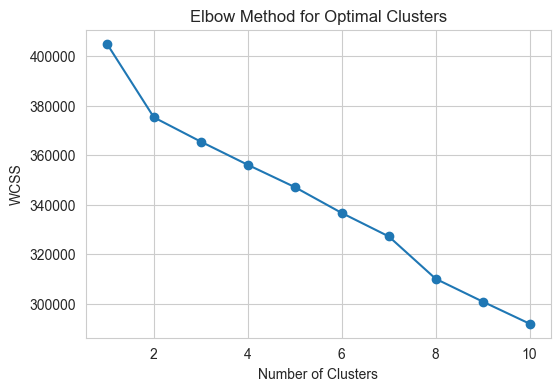

In [7]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


Apply KMeans

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)

df["cluster"] = kmeans.fit_predict(X_scaled)

df["cluster"].value_counts()


cluster
1    5406
0    2865
2     357
3     176
Name: count, dtype: int64

Cluster Analysis

In [9]:
cluster_summary = df.groupby("cluster")[[
    "duration_int",
    "rating_encoded",
    "release_year",
    "content_age"
]].mean()

cluster_summary


,duration_int,rating_encoded,release_year,content_age
cluster,,,,
0,9.593019,8.899476,2016.784642,9.215358
1,102.113578,7.549390,2012.803182,13.196818
2,98.445378,7.285714,2013.719888,12.280112
3,1.573864,8.721591,2015.017045,10.982955


### 5.Classification (Movie vs TV Show)

Prepare Features

In [10]:
drop_cols = [
'show_id','title','director','cast','description',
'duration','duration_type','cluster'
]

X = df.drop(columns=drop_cols + ['is_movie'])

y = df['is_movie']


Train test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42
)


Train Model

In [12]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 6.Model Evaluation

In [13]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9994321408290744

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       566
           1       1.00      1.00      1.00      1195

    accuracy                           1.00      1761
   macro avg       1.00      1.00      1.00      1761
weighted avg       1.00      1.00      1.00      1761



Confusion Matrix

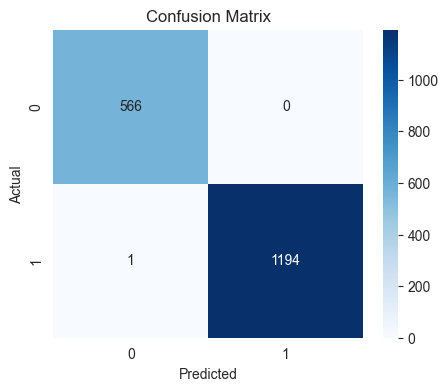

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


### 7.Feature Importance

In [15]:
importance = pd.Series(
model.feature_importances_,
index=X.columns
)

top_features = importance.sort_values(ascending=False).head(10)

top_features


duration_int              0.481353
international tv shows    0.127385
tv dramas                 0.057742
tv comedies               0.052092
kids' tv                  0.038913
international movies      0.036656
docuseries                0.033142
dramas                    0.033066
crime tv shows            0.025068
rating_encoded            0.020769
dtype: float64

Plot Feature Importance

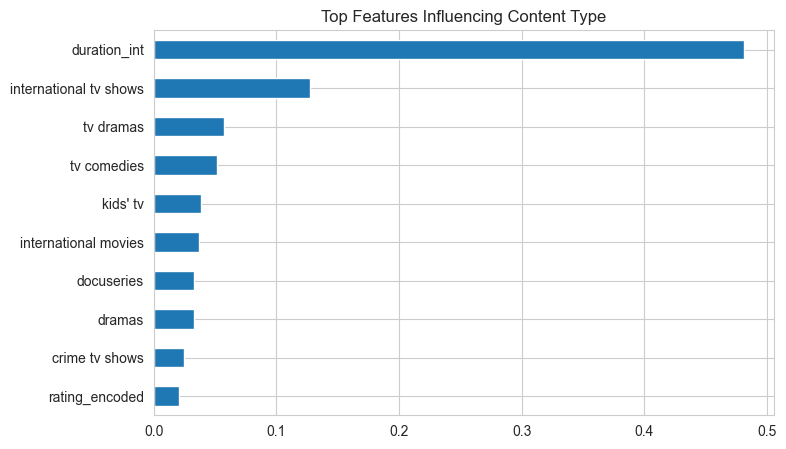

In [16]:
plt.figure(figsize=(8,5))

top_features.sort_values().plot(kind="barh")

plt.title("Top Features Influencing Content Type")
plt.show()


In [20]:
import json
import pandas as pd
from sklearn.cluster import KMeans

df = pd.read_csv("netflix_cleaned.csv")

# Load encoding mappings
with open("encoding_mappings.json") as f:
    mappings = json.load(f)

# Decode rating if needed
if 'rating' not in df.columns and 'rating_encoded' in df.columns:
    rating_map = {v: k for k, v in mappings['rating_mapping'].items()}
    df['rating'] = df['rating_encoded'].map(rating_map)

# Decode country if needed
if 'country' not in df.columns and 'country_encoded' in df.columns:
    country_map = {v: k for k, v in mappings['country_mapping'].items()}
    df['country'] = df['country_encoded'].map(country_map)

# -------- Create cluster column (if not already created) --------

features = df[['duration_int', 'rating_encoded', 'release_year']]

kmeans = KMeans(n_clusters=4, random_state=42)

df['cluster'] = kmeans.fit_predict(features)

# -------- Create dashboard dataset --------

dashboard_data = df[[
    'title',
    'is_movie',
    'release_year',
    'duration_int',
    'rating',
    'country',
    'cluster'
]]

# Save dataset for Streamlit dashboard
dashboard_data.to_csv("netflix_dashboard_data.csv", index=False)

print("Dashboard dataset saved successfully.")
print("Dataset shape:", dashboard_data.shape)

dashboard_data.head()


Dashboard dataset saved successfully.
Dataset shape: (8804, 7)


,title,is_movie,release_year,duration_int,rating,country,cluster
0,Dick Johnson Is Dead,1,2020,90,PG-13,United States,0
1,Blood & Water,0,2021,2,TV-MA,South Africa,1
2,Ganglands,0,2021,1,TV-MA,Unknown,1
3,Jailbirds New Orleans,0,2021,1,TV-MA,Unknown,1
4,Kota Factory,0,2021,2,TV-MA,India,1
